In [28]:
import random
import matplotlib.pyplot as plt

# Data Mata Kuliah dan Dosen
courses = [
("AI","DosenA"),("ML","DosenB"),("DB","DosenC"),
("CN","DosenD"),("SE","DosenE"),("OS","DosenF"),
("IR","DosenA"),("NLP","DosenB"),("CV","DosenC"),
("IOT","DosenD"),("HCI","DosenE"),("CyberSec","DosenF"),
("BigData","DosenA"),("DL","DosenB"),("NoSQL","DosenC"),
("Cloud","DosenD"),("UX","DosenE"),("SecEng","DosenF"),
("Agile","DosenA"),("RL","DosenB"),("ETL","DosenC"),
("DevOps","DosenD"),("GameDev","DosenE"),("Blockchain","DosenF")
]

rooms = ["R1", "R2", "R3", "R4"]

timeslots = [
"Senin-08","Senin-10","Senin-13",
"Selasa-08","Selasa-10","Selasa-13",
"Rabu-08","Rabu-10","Rabu-13",
"Kamis-08","Kamis-10","Kamis-13"
]

POPULATION_SIZE = 60
GENERATIONS = 100
CROSSOVER_RATE = 0.85
MUTATION_RATE = 0.20

print("Jumlah Mata Kuliah:", len(courses))
print("Jumlah Ruang:", len(rooms))
print("Jumlah Slot Waktu:", len(timeslots))

Jumlah Mata Kuliah: 24
Jumlah Ruang: 4
Jumlah Slot Waktu: 12


In [29]:
def create_individual():
    individual = []

    for course in courses:
        room = random.choice(rooms)
        timeslot = random.choice(timeslots)
        individual.append((course[0], course[1], room, timeslot))

    return individual

In [30]:
jadwal = create_individual()

print("===== CONTOH JADWAL =====")

for data in jadwal:
    print(data)

===== CONTOH JADWAL =====
('AI', 'DosenA', 'R1', 'Kamis-08')
('ML', 'DosenB', 'R3', 'Selasa-10')
('DB', 'DosenC', 'R4', 'Selasa-08')
('CN', 'DosenD', 'R2', 'Senin-13')
('SE', 'DosenE', 'R1', 'Kamis-10')
('OS', 'DosenF', 'R3', 'Selasa-13')
('IR', 'DosenA', 'R4', 'Rabu-13')
('NLP', 'DosenB', 'R2', 'Kamis-13')
('CV', 'DosenC', 'R1', 'Senin-13')
('IOT', 'DosenD', 'R3', 'Selasa-13')
('HCI', 'DosenE', 'R4', 'Kamis-10')
('CyberSec', 'DosenF', 'R4', 'Kamis-08')
('BigData', 'DosenA', 'R3', 'Kamis-13')
('DL', 'DosenB', 'R3', 'Rabu-13')
('NoSQL', 'DosenC', 'R4', 'Selasa-13')
('Cloud', 'DosenD', 'R2', 'Kamis-10')
('UX', 'DosenE', 'R2', 'Rabu-08')
('SecEng', 'DosenF', 'R4', 'Senin-08')
('Agile', 'DosenA', 'R1', 'Kamis-10')
('RL', 'DosenB', 'R3', 'Selasa-10')
('ETL', 'DosenC', 'R3', 'Selasa-10')
('DevOps', 'DosenD', 'R2', 'Kamis-08')
('GameDev', 'DosenE', 'R3', 'Kamis-13')
('Blockchain', 'DosenF', 'R2', 'Kamis-13')


In [31]:
def fitness(individual):
    konflik = 0

    room_time = set()
    lecturer_time = set()
    lecturer_day = set()

    for course, lecturer, room, timeslot in individual:

        # Konflik ruang
        if (room, timeslot) in room_time:
            konflik += 1
        else:
            room_time.add((room, timeslot))

        # Konflik dosen pada waktu yang sama
        if (lecturer, timeslot) in lecturer_time:
            konflik += 1
        else:
            lecturer_time.add((lecturer, timeslot))

        # Konflik dosen mengajar lebih dari sekali dalam sehari
        day = timeslot.split("-")[0]

        if (lecturer, day) in lecturer_day:
            konflik += 1
        else:
            lecturer_day.add((lecturer, day))

    nilai_fitness = max(0, 100 - konflik)

    return nilai_fitness, konflik

In [32]:
fit, konflik = fitness(jadwal)

print("Fitness :", fit)
print("Jumlah Konflik :", konflik)

Fitness : 83
Jumlah Konflik : 17


In [33]:
def create_population(size):
    population = []

    for _ in range(size):
        population.append(create_individual())

    return population

In [34]:
population = create_population(60)

print("Jumlah Populasi :", len(population))

Jumlah Populasi : 60


In [35]:
def selection(population):
    population = sorted(population, key=lambda x: fitness(x)[0], reverse=True)
    return population[:30]

In [36]:
selected = selection(population)

print("Jumlah Individu Terpilih :", len(selected))
print("Fitness Terbaik :", fitness(selected[0])[0])

Jumlah Individu Terpilih : 30
Fitness Terbaik : 90


In [37]:
def crossover(parent1, parent2):
    point = random.randint(1, len(parent1) - 1)

    child = parent1[:point] + parent2[point:]

    return child

In [38]:
child = crossover(selected[0], selected[1])

print("Jumlah Gen Anak :", len(child))
print("Fitness Anak :", fitness(child)[0])

Jumlah Gen Anak : 24
Fitness Anak : 94


In [39]:
def mutation(individual):
    new_individual = individual.copy()

    if random.random() < 0.20:
        index = random.randint(0, len(new_individual) - 1)

        course, lecturer, room, timeslot = new_individual[index]

        room = random.choice(rooms)
        timeslot = random.choice(timeslots)

        new_individual[index] = (course, lecturer, room, timeslot)

    return new_individual

In [40]:
mutated = mutation(child)

print("Fitness Sebelum Mutasi :", fitness(child)[0])
print("Fitness Sesudah Mutasi :", fitness(mutated)[0])

Fitness Sebelum Mutasi : 94
Fitness Sesudah Mutasi : 94


In [45]:
best_history = []
avg_history = []

population = create_population(60)

for generation in range(100):

    population = sorted(population, key=lambda x: fitness(x)[0], reverse=True)

    best = fitness(population[0])[0]
    average = sum(fitness(ind)[0] for ind in population) / len(population)

    best_history.append(best)
    avg_history.append(average)

    print(f"Gen {generation+1:3} : Max Fitness = {best:6.2f} | Avg Fitness = {average:6.2f}")

    selected = selection(population)

    new_population = []

    while len(new_population) < 60:
        parent1 = random.choice(selected)
        parent2 = random.choice(selected)

        if random.random() < 0.85:
            child = crossover(parent1, parent2)
        else:
            child = parent1

        child = mutation(child)

        new_population.append(child)

    population = new_population

Gen   1 : Max Fitness =  94.00 | Avg Fitness =  84.92
Gen   2 : Max Fitness =  93.00 | Avg Fitness =  86.48
Gen   3 : Max Fitness =  94.00 | Avg Fitness =  86.88
Gen   4 : Max Fitness =  94.00 | Avg Fitness =  87.97
Gen   5 : Max Fitness =  94.00 | Avg Fitness =  88.60
Gen   6 : Max Fitness =  94.00 | Avg Fitness =  89.12
Gen   7 : Max Fitness =  94.00 | Avg Fitness =  89.50
Gen   8 : Max Fitness =  94.00 | Avg Fitness =  90.45
Gen   9 : Max Fitness =  95.00 | Avg Fitness =  90.88
Gen  10 : Max Fitness =  97.00 | Avg Fitness =  90.80
Gen  11 : Max Fitness =  94.00 | Avg Fitness =  90.83
Gen  12 : Max Fitness =  95.00 | Avg Fitness =  92.07
Gen  13 : Max Fitness =  95.00 | Avg Fitness =  92.93
Gen  14 : Max Fitness =  95.00 | Avg Fitness =  93.52
Gen  15 : Max Fitness =  96.00 | Avg Fitness =  94.05
Gen  16 : Max Fitness =  96.00 | Avg Fitness =  94.03
Gen  17 : Max Fitness =  96.00 | Avg Fitness =  94.27
Gen  18 : Max Fitness =  96.00 | Avg Fitness =  94.50
Gen  19 : Max Fitness =  96.

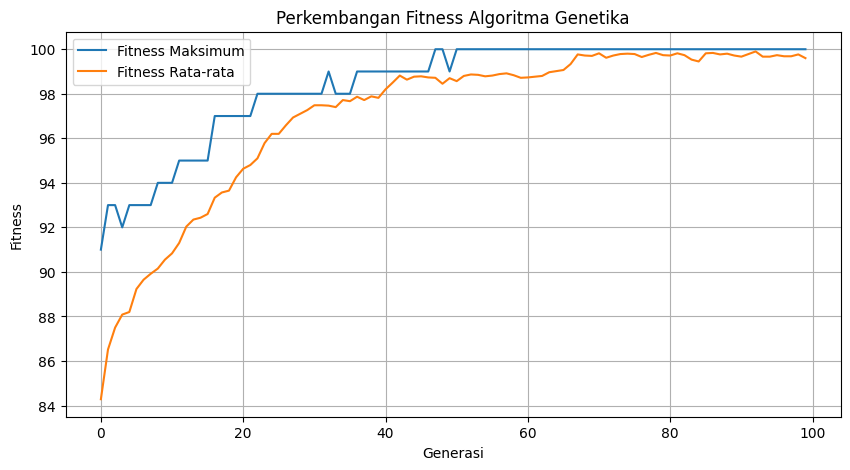

In [42]:
plt.figure(figsize=(10,5))

plt.plot(best_history, label="Fitness Maksimum")
plt.plot(avg_history, label="Fitness Rata-rata")

plt.title("Perkembangan Fitness Algoritma Genetika")
plt.xlabel("Generasi")
plt.ylabel("Fitness")
plt.grid(True)
plt.legend()

plt.show()

In [46]:
best_schedule = sorted(population, key=lambda x: fitness(x)[0], reverse=True)[0]

fitness_terbaik, konflik = fitness(best_schedule)

print("===== JADWAL TERBAIK =====")

for course, lecturer, room, timeslot in best_schedule:
    print(f"MK: {course:<12} | Ruang: {room} | Waktu: {timeslot:<10} | Dosen: {lecturer}")

print("\n===== HASIL EVALUASI AKHIR =====")
print(f"Fitness Terbaik : {fitness_terbaik}")
print(f"Jumlah Konflik  : {konflik}")

===== JADWAL TERBAIK =====
MK: AI           | Ruang: R4 | Waktu: Selasa-10  | Dosen: DosenA
MK: ML           | Ruang: R4 | Waktu: Kamis-13   | Dosen: DosenB
MK: DB           | Ruang: R3 | Waktu: Rabu-13    | Dosen: DosenC
MK: CN           | Ruang: R2 | Waktu: Kamis-10   | Dosen: DosenD
MK: SE           | Ruang: R2 | Waktu: Senin-13   | Dosen: DosenE
MK: OS           | Ruang: R4 | Waktu: Rabu-10    | Dosen: DosenF
MK: IR           | Ruang: R1 | Waktu: Rabu-10    | Dosen: DosenA
MK: NLP          | Ruang: R3 | Waktu: Rabu-08    | Dosen: DosenB
MK: CV           | Ruang: R3 | Waktu: Senin-13   | Dosen: DosenC
MK: IOT          | Ruang: R2 | Waktu: Rabu-10    | Dosen: DosenD
MK: HCI          | Ruang: R3 | Waktu: Selasa-08  | Dosen: DosenE
MK: CyberSec     | Ruang: R3 | Waktu: Kamis-10   | Dosen: DosenF
MK: BigData      | Ruang: R2 | Waktu: Senin-08   | Dosen: DosenA
MK: DL           | Ruang: R1 | Waktu: Senin-10   | Dosen: DosenB
MK: NoSQL        | Ruang: R4 | Waktu: Selasa-13  | Dosen: Dosen